# Thesis Work - March 22nd - Recyclable vs Non-Recyclable Model


## Importing Necessary Libraries

In [ ]:
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Loading the Dataset's Kaggle Path

In [ ]:
path = kagglehub.dataset_download(
    "ashwinshrivastav/most-common-recyclable-and-nonrecyclable-objects"
)

path = Path(path)
print("Dataset downloaded to:", path)

print("\nTop-level contents:")
for p in path.iterdir():
    print("-", p.name, "(dir)" if p.is_dir() else "(file)")

100%|██████████| 66.7M/66.7M [00:00<00:00, 270MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/ashwinshrivastav/most-common-recyclable-and-nonrecyclable-objects/versions/2

Top-level contents:
- Main Dataset (dir)


In [ ]:
base_dir = path / "Main Dataset"
print("Base dir:", base_dir, "| exists:", base_dir.exists())

if not base_dir.exists():
    raise FileNotFoundError("Could not find 'Main Dataset' folder.")

print("\nContents of Main Dataset:")
for p in base_dir.iterdir():
    print("-", p.name)

Base dir: /root/.cache/kagglehub/datasets/ashwinshrivastav/most-common-recyclable-and-nonrecyclable-objects/versions/2/Main Dataset | exists: True

Contents of Main Dataset:
- MILK_CARTON
- CAN
- STYROFOAM
- UTENSIL
- BOTTLE
- JUICE_BOX


In [ ]:
img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

class_dirs = []
for p in base_dir.iterdir():
    if p.is_dir():
        files = list(p.iterdir())
        if any(f.is_file() and f.suffix.lower() in img_exts for f in files):
            class_dirs.append(p)

print("Found class folders:", len(class_dirs))
for c in class_dirs:
    print("-", c.name)

data = []
for c in class_dirs:
    label = c.name
    for f in c.iterdir():
        if f.is_file() and f.suffix.lower() in img_exts:
            data.append((str(f), label))

df = pd.DataFrame(data, columns=["filepath", "label"])

print("Total images:", len(df))
print(df["label"].value_counts())
df.head()

Found class folders: 6
- MILK_CARTON
- CAN
- STYROFOAM
- UTENSIL
- BOTTLE
- JUICE_BOX
Total images: 1558
label
STYROFOAM      395
BOTTLE         393
UTENSIL        391
CAN            225
MILK_CARTON     80
JUICE_BOX       74
Name: count, dtype: int64


,filepath,label
0,/root/.cache/kagglehub/datasets/ashwinshrivast...,MILK_CARTON
1,/root/.cache/kagglehub/datasets/ashwinshrivast...,MILK_CARTON
2,/root/.cache/kagglehub/datasets/ashwinshrivast...,MILK_CARTON
3,/root/.cache/kagglehub/datasets/ashwinshrivast...,MILK_CARTON
4,/root/.cache/kagglehub/datasets/ashwinshrivast...,MILK_CARTON


In [ ]:
recyclable_classes = {"CAN", "BOTTLE", "MILK_CARTON"}
non_recyclable_classes = {"STYROFOAM", "UTENSIL", "JUICE_BOX"}

def map_label(label):
    label = label.upper()
    if label in recyclable_classes:
        return "recyclable"
    elif label in non_recyclable_classes:
        return "non_recyclable"
    else:
        raise ValueError(f"Unknown class: {label}")

df["label"] = df["label"].apply(map_label)

print("\nMapped label distribution:")
print(df["label"].value_counts())


Mapped label distribution:
label
non_recyclable    860
recyclable        698
Name: count, dtype: int64


In [ ]:
SPLIT_ROOT = Path("/content/recyclable_split")
train_out = SPLIT_ROOT / "train"
val_out   = SPLIT_ROOT / "val"
test_out  = SPLIT_ROOT / "test"

if SPLIT_ROOT.exists():
    shutil.rmtree(SPLIT_ROOT)

train_out.mkdir(parents=True, exist_ok=True)
val_out.mkdir(parents=True, exist_ok=True)
test_out.mkdir(parents=True, exist_ok=True)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

def copy_split(split_df, split_dir):
    for label in split_df["label"].unique():
        (split_dir / label).mkdir(parents=True, exist_ok=True)
    for _, row in split_df.iterrows():
        src = Path(row["filepath"])
        dst = split_dir / row["label"] / src.name
        shutil.copy2(src, dst)

copy_split(train_df, train_out)
copy_split(val_df, val_out)
copy_split(test_df, test_out)

Train: 1090 Val: 234 Test: 234


## Adding Generators

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_out,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=SEED,
    shuffle=True
)

val_gen = eval_datagen.flow_from_directory(
    val_out,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=SEED,
    shuffle=False
)

test_gen = eval_datagen.flow_from_directory(
    test_out,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class Indices:", train_gen.class_indices)

Found 1090 images belonging to 2 classes.
Found 234 images belonging to 2 classes.
Found 234 images belonging to 2 classes.
Class Indices: {'non_recyclable': 0, 'recyclable': 1}


## Class Weights

In [ ]:
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_arr))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.9053156146179402), 1: np.float64(1.1168032786885247)}


## Building & Training the DenseNet121 Model

In [ ]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6514 - loss: 0.6457 - val_accuracy: 0.9231 - val_loss: 0.3050 - learning_rate: 1.0000e-04
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 535ms/step - accuracy: 0.8615 - loss: 0.3416 - val_accuracy: 0.9573 - val_loss: 0.1932 - learning_rate: 1.0000e-04
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 504ms/step - accuracy: 0.8945 - loss: 0.2543 - val_accuracy: 0.9615 - val_loss: 0.1558 - learning_rate: 1.0000e-04
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 529ms/step - accuracy: 0.9128 - loss: 0.2195 - val_accuracy: 0.9615 - val_loss: 0.1289 - learning_rate: 1.0000e-04
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 500ms/step - accuracy: 0.9385 - loss: 0.1733 - val_accuracy: 0.9615 - val_loss: 0.1147 - learning_rate: 1.0000e-04
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 514ms/step - accuracy: 0.9413 - loss: 0.1611 - val_accuracy: 0.9658 - val_loss: 0.1023 - learning_rate: 1.0000e-04
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 512ms/step - accura

In [ ]:
# ===========================
# TRAINING RESULTS (ROUND 1)
# ===========================
best_train_acc = max(history.history["accuracy"])
best_val_acc = max(history.history["val_accuracy"])

print("=== ROUND 1 RESULTS ===")
print(f"Best Training Accuracy: {best_train_acc:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

=== ROUND 1 RESULTS ===
Best Training Accuracy: 0.9642
Best Validation Accuracy: 0.9744


## Fine-Tuning

In [ ]:
for layer in base_model.layers[-60:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.9468 - loss: 0.1534 - val_accuracy: 0.9744 - val_loss: 0.0768 - learning_rate: 1.0000e-05
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 551ms/step - accuracy: 0.9578 - loss: 0.1414 - val_accuracy: 0.9786 - val_loss: 0.0764 - learning_rate: 1.0000e-05
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 29s 844ms/step - accuracy: 0.9596 - loss: 0.1249 - val_accuracy: 0.9744 - val_loss: 0.0729 - learning_rate: 1.0000e-05
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 564ms/step - accuracy: 0.9550 - loss: 0.1351 - val_accuracy: 0.9744 - val_loss: 0.0712 - learning_rate: 1.0000e-05
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 539ms/step - accuracy: 0.9633 - loss: 0.1055 - val_accuracy: 0.9786 - val_loss: 0.0715 - learning_rate: 1.0000e-05
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 496ms/step - accuracy: 0.9651 - loss: 0.1095 - val_accuracy: 0.9786 - val_loss: 0.0696 - learning_rate: 1.0000e-05
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 546ms/step - accur

In [ ]:
# =============================
# TRAINING RESULTS (FINE-TUNED)
# =============================
best_train_acc_ft = max(history_ft.history["accuracy"])
best_val_acc_ft = max(history_ft.history["val_accuracy"])

print("=== FINE-TUNING RESULTS ===")
print(f"Best Training Accuracy: {best_train_acc_ft:.4f}")
print(f"Best Validation Accuracy: {best_val_acc_ft:.4f}")

=== FINE-TUNING RESULTS ===
Best Training Accuracy: 0.9706
Best Validation Accuracy: 0.9829


In [ ]:
print(f"Validation Accuracy Improvement: {best_val_acc_ft - best_val_acc:.4f}")

Validation Accuracy Improvement: 0.0085


## Evaluating & Confusion Matrix

8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step 


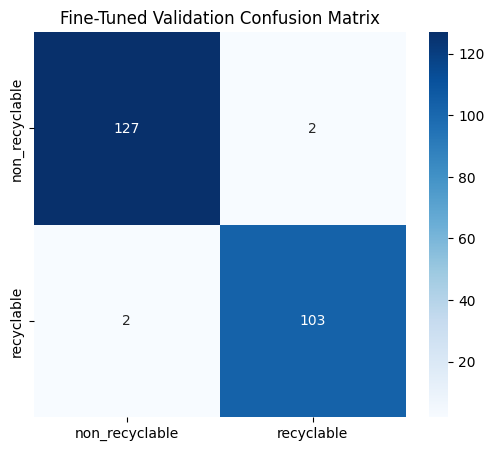

                precision    recall  f1-score   support

non_recyclable       0.98      0.98      0.98       129
    recyclable       0.98      0.98      0.98       105

      accuracy                           0.98       234
     macro avg       0.98      0.98      0.98       234
  weighted avg       0.98      0.98      0.98       234



In [ ]:
val_gen.reset()
test_gen.reset()

val_probs = model.predict(val_gen)
test_probs = model.predict(test_gen)

val_preds = (val_probs > 0.5).astype(int).flatten()
test_preds = (test_probs > 0.5).astype(int).flatten()

val_true = val_gen.classes
test_true = test_gen.classes

class_names = ["non_recyclable", "recyclable"]

cm_val = confusion_matrix(val_true, val_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Fine-Tuned Validation Confusion Matrix")
plt.show()

print(classification_report(val_true, val_preds, target_names=class_names))

## Saving the Model

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/Thesis_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_SAVE_PATH = f"{SAVE_DIR}/DenseNet121_binary_recyclability.keras"
model.save(MODEL_SAVE_PATH)

print("Model saved to:", MODEL_SAVE_PATH)

Mounted at /content/drive
Model saved to: /content/drive/MyDrive/Thesis_Models/DenseNet121_binary_recyclability.keras


In [ ]:
from tensorflow.keras.models import load_model

test_model = load_model(MODEL_SAVE_PATH)
test_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,327,621 (39.40 MB)

 Trainable params: 1,513,729 (5.77 MB)

 Non-trainable params: 5,786,432 (22.07 MB)

 Optimizer params: 3,027,460 (11.55 MB)